## Adaptive RAG

**Adaptive RAG (Retrieval Augmented generation)** is a framework which dynamically adjust its **strategy for handling queries based on their complexity**. It is like having a smart assistant who knows when to dig deep for information and when to provide a simple answer. Instead of using a single, rigid approach, Adaptive RAG chooses the most appropriate retrieval method for each query, **balancing speed and accuracy**. 

**Adaptive RAG** is a strategy for RAG, which combines:
1. Query analysis
2. Active/**Self-corective** RAG

**Self-Reflection** == **Self-corrective RAG**


In [1]:
import os
from dotenv import load_dotenv

env_path = '.env'
assert os.path.exists(env_path)

load_dotenv()

GROQ_API_KEY = os.environ['GROQ_API_KEY']
assert GROQ_API_KEY
print(f'GROQ_API_KEY: {GROQ_API_KEY[:3]}**{GROQ_API_KEY[-3:]}')

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
assert OPENAI_API_KEY
print(f'OPENAI_API_KEY: {OPENAI_API_KEY[:3]}**{OPENAI_API_KEY[-3:]}')

TAVILY_API_KEY = os.environ['TAVILY_API_KEY']
assert TAVILY_API_KEY
print(f'TAVILY_API_KEY: {TAVILY_API_KEY[:3]}**{TAVILY_API_KEY[-3:]}')

## Langsmith for debuging and tracing
LANGCHAIN_API_KEY = os.environ['LANGCHAIN_API_KEY']
assert LANGCHAIN_API_KEY
print(f'LANGCHAIN_API_KEY: {LANGCHAIN_API_KEY[:3]}**{LANGCHAIN_API_KEY[-3:]}')

# Required by LangChain 
LANGCHAIN_TRACING_V2= os.environ['LANGCHAIN_TRACING_V2']
print(f'LANGCHAIN_TRACING_V2: {LANGCHAIN_TRACING_V2}')

LANGCHAIN_PROJECT = os.environ['LANGCHAIN_PROJECT']
print(f'LANGCHAIN_PROJECT: {LANGCHAIN_PROJECT}')

GROQ_API_KEY: gsk**qNU
OPENAI_API_KEY: sk-**tIA
TAVILY_API_KEY: tvl**66J
LANGCHAIN_API_KEY: lsv**43b
LANGCHAIN_TRACING_V2: true
LANGCHAIN_PROJECT: Agentic RAG tutorial


### Build index (Vector store DB)

In [2]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings

# Embeddings
embeddings = OllamaEmbeddings(model='Gemma:2b')

# Document URLs
urls = [
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/',
    'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm'
]

# Text splitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=50)

# Loader 
loader = WebBaseLoader(web_paths=urls)
docs = loader.load_and_split(text_splitter=text_splitter)

# Create Vector database
vector_store = FAISS.from_documents(documents=docs, embedding=embeddings)
retriever = vector_store.as_retriever()
retriever

USER_AGENT environment variable not set, consider setting it to identify your requests.


VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x11a97c830>, search_kwargs={})

### Create router

In [3]:
from langchain_openai import ChatOpenAI
from langchain.chat_models.base import BaseChatModel

def create_llm(cls=ChatOpenAI,
               model_name='gpt-4o-mini',
               temperature=0) -> BaseChatModel:
    return cls(model=model_name, temperature=temperature)

In [4]:
from typing import Literal

from langchain_core.prompts import ChatPromptTemplate

from pydantic import BaseModel, Field

Datasource = Literal['vectorstore', 'web_search']

class RouteQuery(BaseModel):
    """Route a user query to the most relevant datastore."""
    datasource: Datasource = Field(
        description='Given a user question choose to route it to web seach or vector store'
    )

router_llm = create_llm().with_structured_output(RouteQuery)

system_route_prompt = """
You are an expert in routing a user question to either web_search or vector store.
The vectorstore contains documents about AI Agents, prompt engineering and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use web seach. 
"""

route_prompt = ChatPromptTemplate.from_messages(messages=[
    ('system', system_route_prompt),
    ('human', '{question}')
])

router_chain = route_prompt | router_llm

### Create grade document 

In [5]:
# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents
    """
    binary_outcome: Literal['yes', 'no'] = Field(description='Documets are relevant to the question')
    score: float = Field(description="""How confident the model is on document relevance.
                              A coefficient number between 0 and 1.
                              0 - Documents are NOT relevant to the question at all.
                              1 - Documents are completelly relevant to the question.
                              """)

# Create the LLM
grader_llm = create_llm().with_structured_output(GradeDocuments)

# Prompt 
system_prompt = """You are a grader assessing relevance of a retrieved document to a user question.\n
If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant.\n
Give a binary_score ('yes' or 'no') to indicate if the document is relevant or not.\n
Give also a score - a number between 0 and 1 to indicate how relevant the document is to the question.
""" 

grade_prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', 'Document content:\n{context}\n\n\nUser question: {question}\n')
])

retrieval_grader_chain = grade_prompt | grader_llm

### Check for LLM hallucinations

In [6]:
class GradeHallucination(BaseModel):
    """Binary score for hallucination present in the generated answer.
    """
    binary_outcome: Literal['yes', 'no'] = Field(description='Documets are relevant to the question')
    score: float = Field(description="""How the model evaluates if the answes is a hallutination or grouded to facts.
                              A score number between 0 and 1.
                              0 - Answer is a Hallucination.
                              1 - Answer is grouded to facts from the provided documents.
                              """)
    
hallucination_grader = create_llm().with_structured_output(GradeHallucination)

# Prompt 
hallucination_system_prompt = """You are a grader assessing whether an LLM generated answer is grouded in / supported by a set of retrieved facts.\n 
Give a binary_score ('yes' or 'no') to indicate if the answer is based on facts from the provided documents.\n
Give also a score - a number between 0 and 1 to indicate how relevant the document is to the question.
""" 

hallucination_prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', 'Document content:\n{context}\n\n\nGenerated LLM answer: {answer}\n')
])

retrieval_grader_chain = hallucination_prompt | hallucination_grader

In [7]:
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question.
    """
    binary_outcome: Literal['yes', 'no'] = Field(description='Answer addresses the question. "yes" or "no"')
    score: float = Field(description="""How the model evaluates if the answes addresses the question.
                              A score number between 0 and 1.
                              0 - Answer NOT addresses the question.
                              1 - Answer fully addresses the user question.
                              """)
    
answer_grader = create_llm().with_structured_output(GradeAnswer)

# Prompt 
answer_system_prompt = """You are a grader assessing whether an LLM generated answer addresses the user question.\n 
Give a binary_score ('yes' or 'no') to indicate if the answer is answer the question.\n
Give also a score - a number between 0 and 1 to indicate how relevant the answer is to the question.
""" 

answer_prompt = ChatPromptTemplate.from_messages([
    ('system', answer_system_prompt),
    ('human', 'Generated LLM answer: {answer}\n\nUser question: {question}\n')
])

retrieval_grader_chain = answer_prompt | answer_grader

### Question re-writer

In [8]:
from langchain import hub
from langchain_core.output_parsers import StrOutputParser

# Prompt
rag_prompt = hub.pull('rlm/rag-prompt')

rewriter_llm = create_llm()

# Prompt
system_prompt = """You are question re-writer, who converts an input question to a better
version which is optimized for vectorstore retrieval. Look at the input question and try to reason about
the underlying semantic intent/meaning"""
rewriter_promtp = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', 'Input question: {question}\n\n')
])

rewriter_chain = rewriter_promtp | rewriter_llm | StrOutputParser()

### Web seach tool

In [9]:
from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(k=3)

### Graph state

In [10]:
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """Represents the state of the graph."""
    question: str
    generation: str
    documents: List[str]
    route: Literal['web_search', 'self_reflection']

In [11]:
from langchain_core.runnables import Runnable

# Prompt
rag_prompt = hub.pull('rlm/rag-prompt')

def route(state: GraphState) -> Datasource:
    """Decides if we need to send the flow directly to the generate
    or to vector store for retrieving documents."""

    question = state['question']

    router_decision: RouteQuery = router_chain.invoke(input={
        "question": question
    })

    print(f'---Router decision: {router_decision}')

    return router_decision.datasource

### Generate Self-Reflection SubGraph

In [12]:
from typing_extensions import TypedDict, Annotated
from typing import List

DELETE_TOKEN = '__delete__'

def extend_docs(existing: list[str], update: list[str] | str) -> list[str]:
    # Support clear the list
    if update == DELETE_TOKEN:
        return []
    if isinstance(update, str):
        update = [update]
    return (existing or []) + update

class SubGraphState(TypedDict):
    question: str # Input question
    improved_question: str # Improved question
    answer: str # Generated answer
    retrieved_documents: List[str] # List of retrieved documents
    filtered_documents: Annotated[List[str], extend_docs] # Filtered docs 
    hallucination_checks_pass: str = Literal['yes', 'no']

In [13]:
current = ['str1', 'str2']
print(extend_docs(current, 'str3')) # ['str1', 'str2', 'str3']
print(extend_docs(current, ['str3'])) # ['str1', 'str2', 'str3']
print(extend_docs(current, DELETE_TOKEN)) # []

['str1', 'str2', 'str3']
['str1', 'str2', 'str3']
[]


In [14]:
def get_question(state: dict) -> str:
    imp_question = state.get('improved_question')
    if imp_question and len(imp_question) > 0:
        return imp_question
    return state.get('question', '')

In [15]:
print(get_question({ 'question': 'Question?' })) # Question?
print(get_question({ 'improved_question': 'Improved question?' })) # Improved question?
print(get_question({ 'question': 'Question?', 'improved_question': 'Improved question' })) # Improved question?
print(get_question({ })) # ''

Question?
Improved question?
Improved question



#### Retriever

### Grade document

In [16]:
# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents
    """
    binary_outcome: Literal['yes', 'no'] = Field(description='Documets are relevant to the question')
    score: float = Field(description="""How confident the model is on document relevance.
                              A coefficient number between 0 and 1.
                              0 - Documents are NOT relevant to the question at all.
                              1 - Documents are completelly relevant to the question.
                              """)

# Create the LLM
grader_llm = create_llm().with_structured_output(GradeDocuments)

# Prompt 
system_prompt = """You are a grader assessing relevance of a retrieved document to a user question.\n
If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant.\n
Give a binary_score ('yes' or 'no') to indicate if the document is relevant or not.\n
Give also a score - a number between 0 and 1 to indicate how relevant the document is to the question.
""" 

grade_prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', 'Document content:\n{context}\n\n\nUser question: {question}\n')
])

retrieval_grader_chain = grade_prompt | grader_llm

class GradeTaskState(TypedDict):
    question: str
    context: str

def grade(state: GradeTaskState) -> SubGraphState:
    result: GradeDocuments = retrieval_grader_chain.invoke(input=state)
    print(f'---GRADE: Graded document as {result.binary_outcome} with score {result.score}---')
    return { 'filtered_documents': state['context'] if result.binary_outcome == 'yes' else [] }

### Retriever

In [17]:
from langgraph.types import Send

retriever = vector_store.as_retriever()
retriever

def retrieve(state: SubGraphState) -> SubGraphState:
    input_retriever_question = get_question(state)

    print(f'--- RETRIEVE: Question: "{input_retriever_question}"---')

    retrieved_docs = retriever.invoke(input=input_retriever_question)
    
    return {
        'retrieved_documents': [doc.page_content for doc in retrieved_docs]
    }

def fiter_docs(state: SubGraphState) -> SubGraphState:
    grade_requests = [{ 
        'question': get_question(state),
        'context': doc
    } for doc in state.get('retrieved_documents', []) ]

    # Kick off section writting in parallel using Send API
    return [Send('grade_document_relevancy', req) for req in grade_requests]

def syntesize_retrieved(state: SubGraphState) -> SubGraphState:
    return { 'retrieved_documents': state['filtered_documents'] }

In [18]:
def improve_question_gate(state: SubGraphState) -> Literal['improve', 'continue']:
    return 'improve' if len(state.get('filtered_documents', [])) == 0 else 'continue'

def improve_question(state: SubGraphState) -> SubGraphState:
    """Transform question to produce better question optimized for Web search.

    Args:
        state (GraphState): The current state

    Returns:
        GraphState: Updated state
    """
    print(f'---IMPROVE: "{get_question(state)}"---')
    question = get_question(state)
    rewritten_question = rewriter_chain.invoke(input={
        'question': question
    })

    return { 'improved_question': rewritten_question,
             'retrieved_documents': [],
             # Delete Documents
             'filtered_documents': [DELETE_TOKEN] }

In [19]:
# Generate
# Prompt
rag_prompt = hub.pull('rlm/rag-prompt')

def generate_sub_graph(state: SubGraphState) -> SubGraphState:
    """Generate answer

    Args:
        state (GraphState): The current state

    Returns:
        GraphState: Updated state
    """
    print(f'---Generate from subgraph: "{get_question(state)}"---')

    llm = create_llm()

    question = get_question(state)
    context = '\n\n'.join(state['filtered_documents'])

    rag_chain: Runnable = rag_prompt | llm | StrOutputParser()
    generated_response = rag_chain.invoke(input={
        'question': question,
        'context': context
    })
    return { 'answer': generated_response }

In [ ]:
class GradeHallucination(BaseModel):
    """Binary score for hallucination present in the generated answer.
    """
    binary_outcome: Literal['yes', 'no'] = Field(description='Documets are relevant to the question')
    score: float = Field(description="""How the model evaluates if the answes is a hallutination or grouded to facts.
                              A score number between 0 and 1.
                              0 - Answer is a Hallucination.
                              1 - Answer is grouded to facts from the provided documents.
                              """)
    
def hallucination_check(state: SubGraphState) -> SubGraphState:
    hallucination_grader = create_llm().with_structured_output(GradeHallucination)

    # Prompt 
    hallucination_system_prompt = """You are a grader assessing whether an LLM generated answer is grouded in / supported by a set of retrieved facts.\n 
    Give a binary_score ('yes' or 'no') to indicate if the answer is based on facts from the provided documents.\n
    Give also a score - a number between 0 and 1 to indicate how relevant the document is to the question.
    """ 

    hallucination_prompt = ChatPromptTemplate.from_messages([
        ('system', hallucination_system_prompt),
        ('human', '`Facts`:\n{context}\n\n\nGenerated LLM answer: {answer}\n')
    ])

    hallucination_grader_chain = hallucination_prompt | hallucination_grader

    context = '\n\n'.join(state.get('filtered_documents', []))

    response: GradeHallucination = hallucination_grader_chain.invoke({
        'context': context,
        'answer': state['answer']
    })

    print(f'---Halucination check: {response}---')
    return { 'hallucination_checks_pass': response.binary_outcome }
    
def hallucination_grader_gate(state: SubGraphState) -> Literal['yes', 'no']:
    return state.get('hallucination_checks_pass', 'no')
    

### Create Self-Reflection Sub Graph

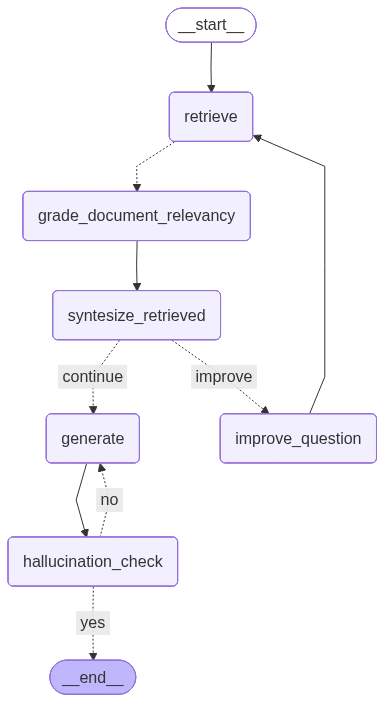

In [21]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

builder = StateGraph(SubGraphState)
# Add Nodes
builder.add_node('retrieve', retrieve)
builder.add_node('grade_document_relevancy', grade)
builder.add_node('syntesize_retrieved', syntesize_retrieved)
builder.add_node('improve_question', improve_question)
builder.add_node('generate', generate_sub_graph)
builder.add_node('hallucination_check', hallucination_check)

# Add Edges
builder.add_edge(START, 'retrieve')
builder.add_conditional_edges('retrieve', fiter_docs, ['grade_document_relevancy'])
builder.add_edge('grade_document_relevancy', 'syntesize_retrieved')
builder.add_conditional_edges('syntesize_retrieved', improve_question_gate, {
    'improve': 'improve_question',
    'continue': 'generate'
})
builder.add_edge('improve_question', 'retrieve')
builder.add_edge('generate', 'hallucination_check')
builder.add_conditional_edges('hallucination_check', hallucination_grader_gate, {
    'yes': END,
    'no': 'generate'
})

sub_graph = builder.compile()

display(Image(sub_graph.get_graph().draw_mermaid_png()))


In [22]:
inp_sub_graph_state: SubGraphState = {
    'question': 'Agentic AI Agent memory?'
}
result = sub_graph.invoke(input=inp_sub_graph_state)
result

--- RETRIEVE: Question: "Agentic AI Agent memory?"---
---GRADE: Graded document as yes with score 0.7---
---GRADE: Graded document as no with score 0.2---
---GRADE: Graded document as no with score 0.0---
---GRADE: Graded document as no with score 0.2---
---Generate from subgraph: "Agentic AI Agent memory?"---
Halucination check: binary_outcome='yes' score=1.0


{'question': 'Agentic AI Agent memory?',
 'answer': "Agentic AI memory refers to a long-term memory module that records an agent's experiences in natural language, allowing it to behave based on past interactions and experiences. This memory enables agents to engage in more realistic and context-aware interactions, similar to human behavior. It is part of the design that combines memory, planning, and reflection mechanisms in generative agents.",
 'retrieved_documents': ['One interesting observation is that while the LLM-based evaluation concluded that GPT-4 and ChemCrow perform nearly equivalently, human evaluations with experts oriented towards the completion and chemical correctness of the solutions showed that ChemCrow outperforms GPT-4 by a large margin. This indicates a potential problem with using LLM to evaluate its own performance on domains that requires deep expertise. The lack of expertise may cause LLMs not knowing its flaws and thus cannot well judge the correctness of ta

## Build main Graph

In [23]:
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)
web_search_tool

/var/folders/g9/x11cjlw56ln82_76czqsvqvr0000gn/T/ipykernel_74771/553480457.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))

In [30]:
def web_search(state: GraphState) -> GraphState:
    """Web search based on rephrased question.

    Args:
        state (GraphState): Current state

    Returns:
        GraphState: Updated state
    """
    print('---Web search---')
    question = state['question']
    documents = state.get('documents', [])

    # Web seach
    docs = web_search_tool.invoke(input=question)
    web_results = '\n'.join([d['content'] for d in docs])
    documents.append(web_results)

    return { 'question': state['question'], 'documents': documents }

def web_generate(state: GraphState) -> GraphState:
    """Generate answer

    Args:
        state (GraphState): The current state

    Returns:
        GraphState: Updated state
    """
    print('---Generate---')

    llm = create_llm()
    
    rag_chain: Runnable = rag_prompt | llm | StrOutputParser()
    generated_response = rag_chain.invoke(input={
        'question': state['question'],
        'context': state['documents']
    })
    return { 'generation': generated_response }

def self_reflection(state: GraphState) -> GraphState:
    sub_graph_state: SubGraphState = { 'question': state['question'] }

    print(f'---Calling Self Reflection sub Graph: "{state["question"]}"---')
    result = sub_graph.invoke(input=sub_graph_state)

    return { 'generation': result['answer'] }

#### Build the graph

In [31]:
graph_builder = StateGraph(GraphState)

graph_builder.add_node('web_search', web_search)
graph_builder.add_node('web_generate', web_generate)
graph_builder.add_node('self_reflection', self_reflection)

graph_builder.add_conditional_edges(START, route, {
    'vectorstore': 'self_reflection',
    'web_search': 'web_search'
})
graph_builder.add_edge('self_reflection', END)
graph_builder.add_edge('web_search', 'web_generate')
graph_builder.add_edge('web_generate', END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

ValueError: Failed to reach https://mermaid.ink/ API while trying to render your graph. Status code: 502.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

In [33]:
input_graph: GraphState = {
    'question': "What is adversarial attach in LLM?"
}

res: GraphState = graph.invoke(input=input_graph)
res

---Router decision: datasource='vectorstore'
---Calling Self Reflection sub Graph: "What is adversarial attach in LLM?"---
--- RETRIEVE: Question: "What is adversarial attach in LLM?"---
---GRADE: Graded document as yes with score 0.7---
---GRADE: Graded document as no with score 0.0---
---GRADE: Graded document as yes with score 0.9---
---GRADE: Graded document as no with score 0.0---
---Generate from subgraph: "What is adversarial attach in LLM?"---
Halucination check: binary_outcome='yes' score=1.0


{'question': 'What is adversarial attach in LLM?',
 'generation': "Adversarial attacks in large language models (LLMs) involve manipulating inputs to produce outputs that violate the model's intended safe behavior, such as generating unsafe content or leaking private information. These attacks can be categorized into white-box and black-box types, depending on the attacker's access to the model's internal details. Techniques like token manipulation are used to subtly alter input tokens while maintaining their semantic meaning to trigger undesired outputs."}